# Next-day product demand forecast



This notebook uses pandas to clean daily coffee-shop sales and trains one global XGBoost model to predict how many units of each menu category will be sold on the day after the latest observation.



The workflow uses a chronological validation period, calculates outlier limits only from earlier training data, and builds lag features only from past sales.

## 1. Install and import dependencies



The cell installs only missing packages, then imports the libraries used below.

In [13]:
import importlib.util

import subprocess

import sys



required_packages = {

    "pandas": "pandas",

    "numpy": "numpy",

    "matplotlib": "matplotlib",

    "sklearn": "scikit-learn",

    "xgboost": "xgboost",

    "joblib": "joblib",

}

missing_packages = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]

if missing_packages:

    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])



from pathlib import Path



import joblib

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor



RANDOM_SEED = 42

pd.set_option("display.max_rows", 100)

pd.set_option("display.max_columns", 50)

print("Ready. Missing packages installed:", missing_packages or "none")

Ready. Missing packages installed: none


## 2. Load CSV files



Find the project data directory, load every CSV with pandas, label its source, and combine all rows.

In [2]:
working_directory = Path.cwd().resolve()

data_candidates = [working_directory / "data", working_directory.parent / "data"]

DATA_DIR = next((path for path in data_candidates if path.exists()), None)

if DATA_DIR is None:

    raise FileNotFoundError("Could not find the data directory. Run this notebook from the project root or src folder.")



csv_files = sorted(DATA_DIR.glob("*.csv"))

if not csv_files:

    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")



frames = []

for csv_file in csv_files:

    frame = pd.read_csv(csv_file)

    frame["Source_File"] = csv_file.name

    frames.append(frame)



raw_sales = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(raw_sales):,} rows from {len(csv_files)} file(s):")

print([path.name for path in csv_files])

Loaded 20,000 rows from 1 file(s):
['coffeeshop_daily_sales_report.csv']


## 3. Inspect and validate the data



Review the data before changing it. The three configuration values below identify the date, product category, and quantity columns.

In [3]:
DATE_COLUMN = "Date"

CATEGORY_COLUMN = "Menu"

TARGET_COLUMN = "Total_Qty"

VALIDATION_DAYS = 30



required_columns = {DATE_COLUMN, CATEGORY_COLUMN, TARGET_COLUMN}

missing_columns = required_columns.difference(raw_sales.columns)

if missing_columns:

    raise ValueError(f"Required columns are missing: {sorted(missing_columns)}")



display(raw_sales.head())

print("Shape:", raw_sales.shape)

print("Columns:", raw_sales.columns.tolist())

display(raw_sales.dtypes.rename("dtype").to_frame())

display(raw_sales.isna().sum().rename("missing_values").to_frame())

print("Exact duplicate rows:", raw_sales.duplicated().sum())

display(raw_sales.describe(include="all").transpose())

,Unnamed: 0,Menu,Day,Promotion,Month,Total_Qty,Sales_Status,Year,Date,Source_File
0,0,Green Tea,Monday,No,1,8,Less Popular,2024,2024-01-01,coffeeshop_daily_sales_report.csv
1,1,Red Velvet Latte,Monday,No,1,15,Best Seller,2024,2024-01-01,coffeeshop_daily_sales_report.csv
2,2,Red Velvet Cake,Monday,Yes,1,13,Less Popular,2024,2024-01-01,coffeeshop_daily_sales_report.csv
3,3,Es Kopi Susu Gula Aren,Monday,No,1,20,Less Popular,2024,2024-01-01,coffeeshop_daily_sales_report.csv
4,4,Chicken Wings,Monday,No,1,18,Less Popular,2024,2024-01-01,coffeeshop_daily_sales_report.csv


Shape: (20000, 10)
Columns: ['Unnamed: 0', 'Menu', 'Day', 'Promotion', 'Month', 'Total_Qty', 'Sales_Status', 'Year', 'Date', 'Source_File']


,dtype
Unnamed: 0,int64
Menu,str
Day,str
Promotion,str
Month,int64
Total_Qty,int64
Sales_Status,str
Year,int64
Date,str
Source_File,str


,missing_values
Unnamed: 0,0
Menu,0
Day,0
Promotion,0
Month,0
Total_Qty,0
Sales_Status,0
Year,0
Date,0
Source_File,0


Exact duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,20000.0,NaN,NaN,NaN,9999.5,5773.647028,0.0,4999.75,9999.5,14999.25,19999.0
Menu,20000,39,Red Velvet Latte,573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,20000,7,Friday,2990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promotion,20000,2,No,13024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,20000.0,NaN,NaN,NaN,6.5122,3.452615,1.0,4.0,7.0,10.0,12.0
Total_Qty,20000.0,NaN,NaN,NaN,18.14535,7.158993,4.0,13.0,17.0,22.0,71.0
Sales_Status,20000,2,Best Seller,10549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,20000.0,NaN,NaN,NaN,2024.50075,0.500012,2024.0,2024.0,2025.0,2025.0,2025.0
Date,20000,731,2024-09-21,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source_File,20000,1,coffeeshop_daily_sales_report.csv,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Clean and preprocess sales data



Parse dates and quantities, standardize category labels, and remove invalid records. Missing or negative quantities cannot represent usable demand and are removed. Repeated date-category rows are valid observations and will be summed in the next section.

In [4]:
sales = raw_sales.copy()

unnamed_columns = [column for column in sales.columns if column.lower().startswith("unnamed:")]

sales = sales.drop(columns=unnamed_columns)

sales[DATE_COLUMN] = pd.to_datetime(sales[DATE_COLUMN], errors="coerce")

sales[TARGET_COLUMN] = pd.to_numeric(sales[TARGET_COLUMN], errors="coerce")

sales[CATEGORY_COLUMN] = sales[CATEGORY_COLUMN].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)



rows_before = len(sales)

sales = sales.drop_duplicates()

valid_rows = (

    sales[DATE_COLUMN].notna()

    & sales[CATEGORY_COLUMN].notna()

    & sales[CATEGORY_COLUMN].ne("")

    & sales[TARGET_COLUMN].notna()

    & sales[TARGET_COLUMN].ge(0)

)

sales = sales.loc[valid_rows].copy()



print(f"Removed {rows_before - len(sales):,} exact duplicate or invalid rows.")

print(f"Clean date range: {sales[DATE_COLUMN].min().date()} to {sales[DATE_COLUMN].max().date()}")

print(f"Product categories: {sales[CATEGORY_COLUMN].nunique()}")

Removed 655 exact duplicate or invalid rows.
Clean date range: 2024-01-01 to 2025-12-31
Product categories: 39


## 5. Aggregate daily sales by category



Sum repeated rows for each day and product. Then create every date-product combination; when a product is absent on a day, interpret it as zero units sold.

In [5]:
daily_sales = (

    sales.groupby([DATE_COLUMN, CATEGORY_COLUMN], as_index=False)[TARGET_COLUMN]

    .sum()

    .sort_values([CATEGORY_COLUMN, DATE_COLUMN])

)



all_dates = pd.date_range(daily_sales[DATE_COLUMN].min(), daily_sales[DATE_COLUMN].max(), freq="D")

all_categories = sorted(daily_sales[CATEGORY_COLUMN].unique())

complete_index = pd.MultiIndex.from_product(

    [all_dates, all_categories], names=[DATE_COLUMN, CATEGORY_COLUMN]

)

daily_sales = (

    daily_sales.set_index([DATE_COLUMN, CATEGORY_COLUMN])

    .reindex(complete_index, fill_value=0)

    .reset_index()

    .sort_values([CATEGORY_COLUMN, DATE_COLUMN])

    .reset_index(drop=True)

)



print(f"Complete panel: {len(all_dates)} days x {len(all_categories)} categories = {len(daily_sales):,} rows")

display(daily_sales.head())

Complete panel: 731 days x 39 categories = 28,509 rows


,Date,Menu,Total_Qty
0,2024-01-01,Affogato,9
1,2024-01-02,Affogato,20
2,2024-01-03,Affogato,9
3,2024-01-04,Affogato,0
4,2024-01-05,Affogato,0


## 6. Remove sales outliers



Use the 1.5 x IQR rule separately for each product. Bounds are calculated only from dates before validation, preventing future validation data from influencing training cleanup. Outlier target rows are excluded from model fitting; the untouched validation period remains suitable for honest evaluation.

Training outliers marked for removal: 796


,Q1,Q3,IQR,Lower_Bound,Upper_Bound
Menu,,,,,
Affogato,0.0,10.0,10.0,0.0,25.0
Americano,0.0,21.0,21.0,0.0,52.5
Brownies,0.0,19.0,19.0,0.0,47.5
Burger,0.0,18.0,18.0,0.0,45.0
Cappuccino,0.0,24.0,24.0,0.0,60.0


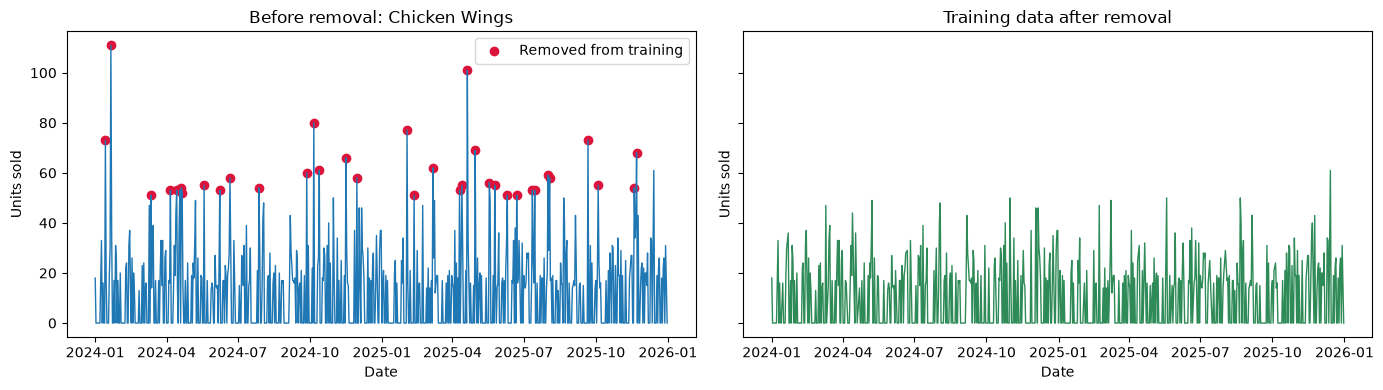

In [6]:
validation_start = daily_sales[DATE_COLUMN].max() - pd.Timedelta(days=VALIDATION_DAYS - 1)

bounds_source = daily_sales.loc[daily_sales[DATE_COLUMN] < validation_start]

category_quartiles = bounds_source.groupby(CATEGORY_COLUMN)[TARGET_COLUMN].quantile([0.25, 0.75]).unstack()

category_quartiles.columns = ["Q1", "Q3"]

category_quartiles["IQR"] = category_quartiles["Q3"] - category_quartiles["Q1"]

category_quartiles["Lower_Bound"] = (category_quartiles["Q1"] - 1.5 * category_quartiles["IQR"]).clip(lower=0)

category_quartiles["Upper_Bound"] = category_quartiles["Q3"] + 1.5 * category_quartiles["IQR"]



daily_sales = daily_sales.join(

    category_quartiles[["Lower_Bound", "Upper_Bound"]], on=CATEGORY_COLUMN

)

daily_sales["Is_Outlier"] = (

    (daily_sales[DATE_COLUMN] < validation_start)

    & ~daily_sales[TARGET_COLUMN].between(daily_sales["Lower_Bound"], daily_sales["Upper_Bound"])

)

print(f"Training outliers marked for removal: {daily_sales['Is_Outlier'].sum():,}")

display(category_quartiles.head())



plot_category = daily_sales.groupby(CATEGORY_COLUMN)["Is_Outlier"].sum().idxmax()

plot_data = daily_sales.loc[daily_sales[CATEGORY_COLUMN] == plot_category]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(plot_data[DATE_COLUMN], plot_data[TARGET_COLUMN], linewidth=1)

axes[0].scatter(

    plot_data.loc[plot_data["Is_Outlier"], DATE_COLUMN],

    plot_data.loc[plot_data["Is_Outlier"], TARGET_COLUMN],

    color="crimson", label="Removed from training"

)

axes[0].set_title(f"Before removal: {plot_category}")

axes[0].legend()

clean_plot_data = plot_data.loc[~plot_data["Is_Outlier"]]

axes[1].plot(clean_plot_data[DATE_COLUMN], clean_plot_data[TARGET_COLUMN], linewidth=1, color="seagreen")

axes[1].set_title("Training data after removal")

for axis in axes:

    axis.set_xlabel("Date")

    axis.set_ylabel("Units sold")

plt.tight_layout()

plt.show()

## 7. Create time-series features



Add calendar fields plus category-specific lags and rolling averages. Every sales feature is shifted first, so it contains only information available before the forecast date.

In [7]:
def create_time_features(data):

    featured = data.sort_values([CATEGORY_COLUMN, DATE_COLUMN]).copy()

    featured["Day_Of_Week"] = featured[DATE_COLUMN].dt.dayofweek

    featured["Month"] = featured[DATE_COLUMN].dt.month

    featured["Day_Of_Month"] = featured[DATE_COLUMN].dt.day

    featured["Day_Of_Year"] = featured[DATE_COLUMN].dt.dayofyear

    featured["Is_Weekend"] = featured["Day_Of_Week"].isin([5, 6]).astype(int)



    grouped_sales = featured.groupby(CATEGORY_COLUMN)[TARGET_COLUMN]

    for lag in [1, 7, 14, 28]:

        featured[f"Lag_{lag}"] = grouped_sales.shift(lag)

    for window in [7, 14, 28]:

        featured[f"Rolling_Mean_{window}"] = grouped_sales.transform(

            lambda values: values.shift(1).rolling(window).mean()

        )

        featured[f"Rolling_Std_{window}"] = grouped_sales.transform(

            lambda values: values.shift(1).rolling(window).std()

        )

    return featured



featured_sales = create_time_features(daily_sales)

history_features = [column for column in featured_sales.columns if column.startswith(("Lag_", "Rolling_"))]

featured_sales = featured_sales.dropna(subset=history_features).reset_index(drop=True)

print(f"Rows available after 28 days of feature history: {len(featured_sales):,}")

display(featured_sales.head())

Rows available after 28 days of feature history: 27,417


,Date,Menu,Total_Qty,Lower_Bound,Upper_Bound,Is_Outlier,Day_Of_Week,Month,Day_Of_Month,Day_Of_Year,Is_Weekend,Lag_1,Lag_7,Lag_14,Lag_28,Rolling_Mean_7,Rolling_Std_7,Rolling_Mean_14,Rolling_Std_14,Rolling_Mean_28,Rolling_Std_28
0,2024-01-29,Affogato,0,0.0,25.0,False,0,1,29,29,0,17.0,9.0,0.0,9.0,7.428571,7.678045,6.285714,7.205004,7.464286,8.011483
1,2024-01-30,Affogato,0,0.0,25.0,False,1,1,30,30,0,0.0,0.0,0.0,20.0,6.142857,8.112307,6.285714,7.205004,7.142857,8.127294
2,2024-01-31,Affogato,9,0.0,25.0,False,2,1,31,31,0,0.0,0.0,0.0,9.0,6.142857,8.112307,6.285714,7.205004,6.428571,7.828857
3,2024-02-01,Affogato,9,0.0,25.0,False,3,2,1,32,0,9.0,9.0,8.0,0.0,7.428571,7.678045,6.928571,6.999608,6.428571,7.828857
4,2024-02-02,Affogato,13,0.0,25.0,False,4,2,2,33,0,9.0,0.0,10.0,0.0,7.428571,7.678045,7.000000,7.016464,6.750000,7.739389


## 8. Create a chronological train-validation split



Use all clean observations before the final 30 days for training. Random splitting would let future behavior leak into the training set and would overstate forecasting accuracy.

In [8]:
feature_columns = [

    CATEGORY_COLUMN, "Day_Of_Week", "Month", "Day_Of_Month", "Day_Of_Year", "Is_Weekend",

    *history_features,

]

train_mask = (featured_sales[DATE_COLUMN] < validation_start) & ~featured_sales["Is_Outlier"]

validation_mask = featured_sales[DATE_COLUMN] >= validation_start



train_data = featured_sales.loc[train_mask].copy()

validation_data = featured_sales.loc[validation_mask].copy()

X_train = pd.get_dummies(train_data[feature_columns], columns=[CATEGORY_COLUMN], dtype=int)

X_validation = pd.get_dummies(validation_data[feature_columns], columns=[CATEGORY_COLUMN], dtype=int)

X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0)

y_train = train_data[TARGET_COLUMN]

y_validation = validation_data[TARGET_COLUMN]



print(f"Training: {train_data[DATE_COLUMN].min().date()} to {train_data[DATE_COLUMN].max().date()}, {len(train_data):,} rows")

print(f"Validation: {validation_data[DATE_COLUMN].min().date()} to {validation_data[DATE_COLUMN].max().date()}, {len(validation_data):,} rows")

print("Model features:", X_train.shape[1])

Training: 2024-01-29 to 2025-12-01, 25,485 rows
Validation: 2025-12-02 to 2025-12-31, 1,170 rows
Model features: 54


## 9. Train the XGBoost model



Train one model across all products. The Poisson objective is designed for non-negative count-like targets, and one-hot columns allow each menu category to have its own learned effect.

In [9]:
model = XGBRegressor(

    objective="count:poisson",

    n_estimators=400,

    learning_rate=0.05,

    max_depth=6,

    min_child_weight=3,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_lambda=1.0,

    random_state=RANDOM_SEED,

    n_jobs=-1,

    eval_metric="mae",

)

model.fit(X_train, y_train, eval_set=[(X_validation, y_validation)], verbose=False)

print("Model training complete.")

Model training complete.


## 10. Evaluate forecast accuracy



Report MAE, RMSE, and WMAPE overall and by product. WMAPE is total absolute error divided by total actual demand, which makes it useful for comparing aggregate business impact.

,Overall
MAE,12.873915
RMSE,16.301986
WMAPE_Percent,102.605453


,MAE,RMSE,WMAPE_Percent
Menu,,,
Muffin,11.985355,13.884084,71.341398
Red Velvet Cake,9.993233,11.930247,77.869350
Flat White,11.357747,14.021035,82.104192
Pain au Chocolat,14.322190,17.571867,83.755496
Americano,14.739218,17.538601,84.063979
Burger,15.771378,20.746722,84.489523
Matcha Latte,20.003313,24.014304,85.484245
Espresso,9.479712,12.375243,85.918837
Spaghetti,11.433443,14.226117,88.631338


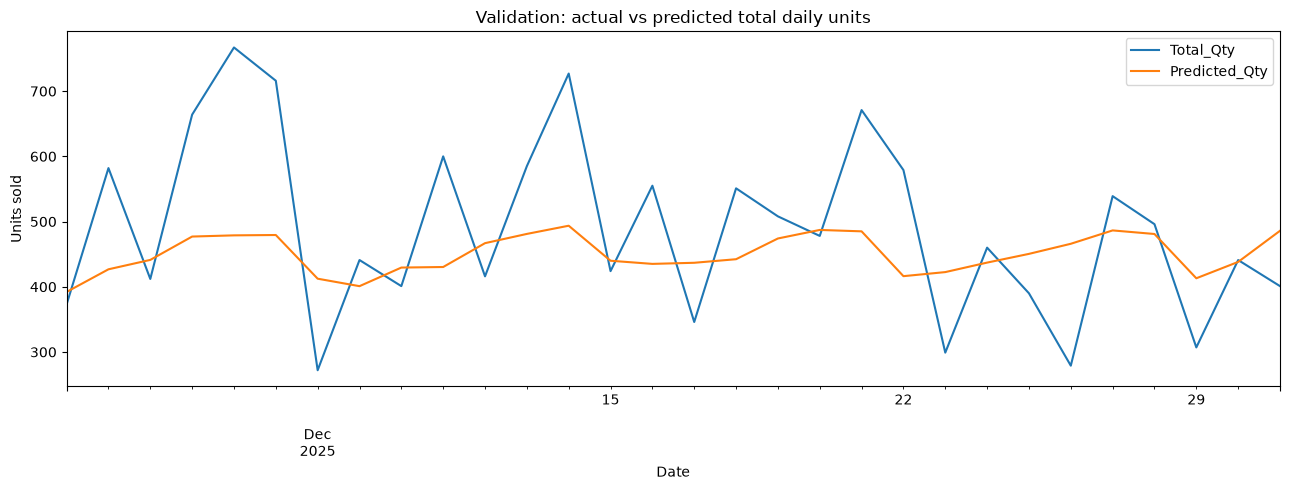

In [10]:
validation_predictions = np.clip(model.predict(X_validation), 0, None)

evaluation = validation_data[[DATE_COLUMN, CATEGORY_COLUMN, TARGET_COLUMN]].copy()

evaluation["Predicted_Qty"] = validation_predictions

evaluation["Absolute_Error"] = (evaluation[TARGET_COLUMN] - evaluation["Predicted_Qty"]).abs()



overall_metrics = pd.Series({

    "MAE": mean_absolute_error(evaluation[TARGET_COLUMN], evaluation["Predicted_Qty"]),

    "RMSE": mean_squared_error(evaluation[TARGET_COLUMN], evaluation["Predicted_Qty"]) ** 0.5,

    "WMAPE_Percent": 100 * evaluation["Absolute_Error"].sum() / evaluation[TARGET_COLUMN].sum(),

}, name="Overall")

display(overall_metrics.to_frame())



category_metrics = evaluation.groupby(CATEGORY_COLUMN).apply(

    lambda group: pd.Series({

        "MAE": group["Absolute_Error"].mean(),

        "RMSE": np.sqrt(np.mean((group[TARGET_COLUMN] - group["Predicted_Qty"]) ** 2)),

        "WMAPE_Percent": 100 * group["Absolute_Error"].sum() / max(group[TARGET_COLUMN].sum(), 1),

    }),

    include_groups=False,

).sort_values("WMAPE_Percent")

display(category_metrics)



daily_evaluation = evaluation.groupby(DATE_COLUMN)[[TARGET_COLUMN, "Predicted_Qty"]].sum()

daily_evaluation.plot(figsize=(13, 5), title="Validation: actual vs predicted total daily units")

plt.ylabel("Units sold")

plt.tight_layout()

plt.show()

## 11. Predict incoming-day sales by category



Append one placeholder row per product for the day after the latest observed date. Feature creation reads the real history through the prior day; the placeholder target itself is never used because all demand features are shifted. Predictions are rounded to whole units.

In [11]:
forecast_date = daily_sales[DATE_COLUMN].max() + pd.Timedelta(days=1)

future_rows = pd.DataFrame({

    DATE_COLUMN: forecast_date,

    CATEGORY_COLUMN: all_categories,

    TARGET_COLUMN: 0.0,

    "Lower_Bound": np.nan,

    "Upper_Bound": np.nan,

    "Is_Outlier": False,

})

history_and_future = pd.concat([daily_sales, future_rows], ignore_index=True)

future_features = create_time_features(history_and_future)

future_features = future_features.loc[future_features[DATE_COLUMN] == forecast_date].copy()



X_future = pd.get_dummies(future_features[feature_columns], columns=[CATEGORY_COLUMN], dtype=int)

X_future = X_future.reindex(columns=X_train.columns, fill_value=0)

future_predictions = np.clip(model.predict(X_future), 0, None)



next_day_forecast = future_features[[DATE_COLUMN, CATEGORY_COLUMN]].copy()

next_day_forecast["Predicted_Qty"] = np.rint(future_predictions).astype(int)

next_day_forecast = next_day_forecast.sort_values("Predicted_Qty", ascending=False).reset_index(drop=True)

display(next_day_forecast)

print("Predicted total units:", next_day_forecast["Predicted_Qty"].sum())

,Date,Menu,Predicted_Qty
0,2026-01-01,Cappuccino,21
1,2026-01-01,Iced Americano,15
2,2026-01-01,Croissant,15
3,2026-01-01,Red Velvet Latte,15
4,2026-01-01,Latte,15
5,2026-01-01,Es Kopi Susu Gula Aren,14
6,2026-01-01,Cinnamon Roll,13
7,2026-01-01,Macchiato,13
8,2026-01-01,French Fries,13
9,2026-01-01,Matcha Latte,12


Predicted total units: 407


## 12. Save predictions and model artifacts



Save the incoming-day forecast as CSV plus the fitted model and preprocessing metadata needed to reproduce the model inputs.

In [12]:
OUTPUT_DIR = DATA_DIR.parent / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



prediction_path = OUTPUT_DIR / "next_day_product_forecast.csv"

model_path = OUTPUT_DIR / "xgb_daily_product_demand.json"

metadata_path = OUTPUT_DIR / "forecast_metadata.joblib"



next_day_forecast.to_csv(prediction_path, index=False)

model.save_model(model_path)

artifacts = {

    "model_feature_columns": X_train.columns.tolist(),

    "raw_feature_columns": feature_columns,

    "categories": all_categories,

    "category_dummy_columns": [column for column in X_train.columns if column.startswith(f"{CATEGORY_COLUMN}_")],

    "configuration": {

        "date_column": DATE_COLUMN,

        "category_column": CATEGORY_COLUMN,

        "target_column": TARGET_COLUMN,

        "validation_days": VALIDATION_DAYS,

        "random_seed": RANDOM_SEED,

    },

    "outlier_bounds": category_quartiles.reset_index(),

    "validation_metrics": overall_metrics.to_dict(),

}

joblib.dump(artifacts, metadata_path)



print("Saved predictions:", prediction_path)

print("Saved XGBoost model:", model_path)

print("Saved metadata:", metadata_path)

Saved predictions: C:\Workdir\interview\outputs\next_day_product_forecast.csv
Saved XGBoost model: C:\Workdir\interview\outputs\xgb_daily_product_demand.json
Saved metadata: C:\Workdir\interview\outputs\forecast_metadata.joblib
